# 41 — Object detection architectures

The [previous notebooks](./40_detection_evaluation.ipynb) studied boxes, IoU, post-processing, and evaluation. We now connect those pieces to the structure of an object detector.

In this notebook we will:

- interpret dense predictions made from a convolutional feature map;
- construct anchors and assign training labels with IoU;
- understand why RoI pooling creates fixed-size region features;
- compare two-stage and one-stage detection pipelines;
- see why feature pyramids help detect objects at different scales;
- place R-CNN, Fast/Faster R-CNN, SSD, YOLO, RetinaNet, and anchor-free detectors in one conceptual map.

The goal is architecture intuition. We use small NumPy examples rather than train a full detector.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch

from cs231n_practice.detection import pairwise_box_iou

np.set_printoptions(precision=3, suppress=True)

## 1. From an image to dense predictions

A CNN backbone converts an image into one or more feature maps. A detection head is applied across their spatial locations. Instead of producing one class score for the complete image, it produces many candidate predictions.

For a feature map of height $H$ and width $W$, with $A$ candidate boxes per location, the detector produces

$$HWA$$

candidate predictions per image. Each candidate commonly predicts $C$ class values and 4 box-regression values. Some architectures also predict a separate objectness value. The feature-map cell is not necessarily the final box: it is the location from which a box is proposed or decoded.

### Exercise 1 — Calculate dense output shapes

For an $8\times8$ feature map, 3 candidates per location, and 10 object classes, calculate the number of candidate boxes and the number of output channels for a head that predicts 10 class logits plus 4 box offsets per candidate.

In [19]:
feature_height = 8
feature_width = 8
candidates_per_location = 3
number_of_classes = 10

# calculate the number of candidates and output channels.
number_of_candidates = feature_height * feature_width * candidates_per_location
channels_per_candidate = number_of_classes + 4  # +4 for bounding box coordinates
head_output_channels = candidates_per_location * channels_per_candidate

assert number_of_candidates == 192
assert channels_per_candidate == 14
assert head_output_channels == 42
print(f"Candidates per image: {number_of_candidates}")
print(f"Head output shape: (N, {head_output_channels}, 8, 8)")

Candidates per image: 192
Head output shape: (N, 42, 8, 8)


## 2. Anchors: reference boxes for prediction

An **anchor** is a predefined reference box attached to a feature-map location. Several scales and aspect ratios let one location represent objects of different shapes. The network does not normally accept the anchor unchanged; it predicts offsets that move and resize it toward an object.

Let $s$ be the square root of anchor area and let $r=w/h$ be its aspect ratio. These definitions give us two equations:

$$wh=s^2, \qquad \frac{w}{h}=r.$$

From the aspect-ratio equation, $w=rh$. Substitute this into the area equation:

$$wh=s^2 \quad\Longrightarrow\quad (rh)h=s^2 \quad\Longrightarrow\quad h^2=\frac{s^2}{r}.$$

Widths and heights are positive, so taking the square root gives

$$h=\frac{s}{\sqrt{r}}.$$

Finally, substitute this result into $w=rh$:

$$w=r\frac{s}{\sqrt{r}}=s\sqrt{r}.$$

Therefore,

$$w=s\sqrt{r}, \qquad h=\frac{s}{\sqrt{r}}.$$

This changes the anchor's shape while preserving its area:

$$wh=\left(s\sqrt{r}\right)\left(\frac{s}{\sqrt{r}}\right)=s^2.$$

For example, with $s=16$, all of the ratios below produce area $16^2=256$:

- $r=1$ gives $w=16$ and $h=16$;
- $r=2$ gives $w\approx22.63$ and $h\approx11.31$;
- $r=0.5$ gives $w\approx11.31$ and $h\approx22.63$.

A center $(c_x,c_y)$ and size $(w,h)$ become corner coordinates

$$[c_x-w/2,\;c_y-h/2,\;c_x+w/2,\;c_y+h/2].$$

### Exercise 2 — Generate anchors at one location

In [5]:
def anchors_at_location(center_x, center_y, scales, aspect_ratios):
    """Return one xyxy anchor for every scale-ratio combination."""
    anchors = []
    for scale in scales:
        for ratio in aspect_ratios:
            # calculate width and height, then append xyxy corners.
            width = scale * np.sqrt(ratio)
            height = scale / np.sqrt(ratio)
            x1 = center_x - width / 2
            y1 = center_y - height / 2
            x2 = center_x + width / 2
            y2 = center_y + height / 2
            anchors.append([x1, y1, x2, y2])
    return np.asarray(anchors, dtype=float)

anchors = anchors_at_location(32, 32, scales=[16, 32], aspect_ratios=[0.5, 1, 2])
assert anchors.shape == (6, 4)
anchor_sizes = anchors[:, 2:] - anchors[:, :2]
np.testing.assert_allclose(anchor_sizes[:, 0] * anchor_sizes[:, 1], [256] * 3 + [1024] * 3)
np.testing.assert_allclose(anchors[[1, 4]], [[24, 24, 40, 40], [16, 16, 48, 48]])
print(anchors)

[[26.343 20.686 37.657 43.314]
 [24.    24.    40.    40.   ]
 [20.686 26.343 43.314 37.657]
 [20.686  9.373 43.314 54.627]
 [16.    16.    48.    48.   ]
 [ 9.373 20.686 54.627 43.314]]


## 3. Assigning anchors during training

Training needs a target for each anchor. A simplified assignment policy is:

- **positive** (`1`) when its best IoU is at least the positive threshold;
- **negative** (`0`) when its best IoU is below the negative threshold;
- **ignore** (`-1`) between the thresholds.

Ignored anchors contribute neither positive nor negative classification loss. The gap prevents ambiguous borderline anchors from dominating training. Positive anchors also receive box-regression targets. Real detectors add policies such as forcing every ground-truth object to have a positive match.

### Exercise 3 — Assign positive, negative, and ignored anchors

In [7]:
def assign_anchors(anchors, target_boxes, positive_iou=0.5, negative_iou=0.3):
    """Assign 1, 0, or -1 from each anchor's greatest target IoU."""
    if negative_iou > positive_iou:
        raise ValueError("negative_iou must not exceed positive_iou")
    # calculate best IoU per anchor and create the label array.
    best_iou = pairwise_box_iou(anchors, target_boxes).max(axis=1)
    labels = np.full(anchors.shape[0], -1, dtype=int)
    labels[best_iou >= positive_iou] = 1
    labels[best_iou < negative_iou] = 0
    return labels, best_iou

training_anchors = np.array([
    [20, 20, 44, 44],  # exact match
    [18, 18, 46, 46],  # strong overlap
    [10, 10, 30, 30],  # weak overlap
    [0, 0, 10, 10],    # no overlap
    [15, 15, 40, 40],  # borderline overlap
], dtype=float)
training_targets = np.array([[20, 20, 44, 44]], dtype=float)
anchor_labels, best_anchor_iou = assign_anchors(training_anchors, training_targets)
np.testing.assert_array_equal(anchor_labels, [1, 1, 0, 0, -1])
print("Best IoU:    ", best_anchor_iou)
print("Anchor label:", anchor_labels)

Best IoU:     [1.    0.735 0.114 0.    0.499]
Anchor label: [ 1  1  0  0 -1]


## 4. Two-stage detectors and region features

A **two-stage detector** does not immediately treat every dense candidate as a final detection. Its first stage finds a smaller collection of promising rectangular regions. Its second stage then examines each region more carefully.

The R-CNN family therefore separates detection into proposal and classification stages:

1. propose regions likely to contain objects;
2. extract a fixed-size feature for each proposed region;
3. classify the region and refine its box.

A **proposal**, also called a Region of Interest (RoI), is only a candidate box that may contain an object. It is not yet a final detection. For example, the first stage may propose one small box around a cat and one larger box around a car. The second stage assigns their final class scores and refines their coordinates.

### Why shared features matter

Original **R-CNN** first generated external region proposals, cropped each proposed region from the image, resized it, and ran the CNN separately for every proposal. It commonly used **Selective Search**, a separate hand-designed algorithm that groups visually similar image regions and proposes boxes that may contain objects. It is called *external* because it is outside the neural network: its behavior is not learned jointly with the detector and cannot be improved through the detector's backpropagation. With hundreds or thousands of proposals, much of the same image was processed repeatedly.

**Fast R-CNN** reversed that order:

1. run the image through the CNN once to produce one shared feature map;
2. map each proposal box from image coordinates onto that feature map;
3. extract a fixed-size feature tensor for each proposal;
4. send those tensors through the second-stage classification and box-regression head.

**Faster R-CNN** kept this shared computation but replaced the external proposal algorithm with a learned **Region Proposal Network (RPN)**. The RPN operates on the same backbone feature map and predicts objectness and proposal boxes. This is the first stage; the RoI head is the second stage.

### Why RoI Pooling is needed

Proposal regions have different spatial sizes. One mapped proposal might cover a $4\times6$ feature region while another covers $10\times8$. A conventional second-stage head and a batch of tensors need consistent dimensions, so these variable-size regions cannot be passed onward directly.

RoI Pooling solves this by dividing every proposal region into the same fixed number of bins—for example, $7\times7$—regardless of its original size. It takes the maximum activation inside every bin. If the shared feature map has $C$ channels, each proposal consequently becomes a fixed tensor of shape $(C,7,7)$. The bins are fixed in number, not fixed in their original width and height.

This operation keeps a summary of the strongest activation in each part of the region while discarding some exact spatial detail. **RoI Align** improves the idea by avoiding coarse rounding of proposal coordinates and sampling feature values with interpolation.

### Exercise 4 — Perform a tiny $2\times2$ RoI max pool

The exercise isolates only the pooling step. Its $4\times4$ array represents **one channel of the feature region already selected for one proposal**. For simplicity, the proposal covers this complete array and divides evenly into a $2\times2$ output grid. Real RoI Pooling repeats the same operation independently for every channel and proposal.

The four input bins and their maxima are:

```text
top-left             top-right
[[0, 1],             [[2, 3],
 [4, 5]] -> 5         [6, 7]] -> 7

bottom-left          bottom-right
[[ 8,  9],           [[10, 11],
 [12, 13]] -> 13      [14, 15]] -> 15
```

The fixed-size result is therefore

$$\begin{bmatrix}5 & 7 \\ 13 & 15\end{bmatrix}.$$

A larger proposal would contain larger bins, but it would still produce exactly four values in this simplified $2\times2$ example. That fixed output shape is the connection between the exercise and the two-stage architecture.

### What if the region does not divide evenly?

The bins do not need to contain the same number of feature values. For a $5\times5$ region pooled to $2\times2$, a simple non-overlapping split could use row ranges `[0:2]`, `[2:5]` and the same column ranges. The four bins would then have shapes $2\times2$, $2\times3$, $3\times2$, and $3\times3$. Each bin still contributes one maximum, so the output remains $2\times2$.

Similarly, a $5\times7$ region could use:

```text
row ranges:    [0:2] and [2:5]
column ranges: [0:3] and [3:7]

bin shapes:    2x3   2x4
               3x3   3x4
```

Classic RoI Pooling commonly obtains integer boundaries by rounding fractional bin boundaries. A typical rule for output-bin index $i$ is

$$\mathrm{start}_i=\left\lfloor\frac{iH}{H_{out}}\right\rfloor, \qquad \mathrm{end}_i=\left\lceil\frac{(i+1)H}{H_{out}}\right\rceil.$$

The same rule is applied across the width. With floor and ceiling, adjacent bins can sometimes share a boundary row or column; exact conventions vary by implementation. This coordinate quantization is why RoI Align instead samples at fractional positions using interpolation.

In [9]:
def roi_max_pool_2x2(feature_region):
    """Pool an even-sized 2D region into a 2x2 output."""
    height, width = feature_region.shape
    if height % 2 != 0 or width % 2 != 0:
        raise ValueError("region dimensions must be divisible by 2")
    pooled = np.empty((2, 2), dtype=feature_region.dtype)
    bin_height = height // 2
    bin_width = width // 2
    for row in range(2):
        for column in range(2):
            # select this bin and store its maximum.
            bin_region = feature_region[row * bin_height:(row + 1) * bin_height,
                                        column * bin_width:(column + 1) * bin_width]
            pooled[row, column] = np.max(bin_region)
    return pooled

feature_map = np.arange(16).reshape(4, 4)
pooled_features = roi_max_pool_2x2(feature_map)
np.testing.assert_array_equal(pooled_features, [[5, 7], [13, 15]])
print("Feature map:", feature_map)
print("Pooled region:", pooled_features)

Feature map: [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
Pooled region: [[ 5  7]
 [13 15]]


## 5. One-stage detectors

A **one-stage detector** predicts final class scores and box coordinates directly from dense feature-map locations. It does not first create a short proposal list and then run a separate RoI classification head on every proposal. SSD and YOLO are well-known examples.

The word *one-stage* does **not** mean that the model has only one neural-network layer or performs only one mathematical operation. It can have a large backbone, an FPN, and several head layers. The name refers specifically to the absence of a separate learned proposal-to-RoI classification stage.

### Following one dense candidate

Imagine one feature-map cell whose receptive field contains a cat. For one anchor attached to that cell, the detection head may output:

- class scores such as `cat=0.90`, `dog=0.03`, and `car=0.01`;
- four offsets that move and resize the anchor into a tighter cat box;
- optionally, a separate objectness score.

After decoding the offsets, that output is already a final detection **candidate**. The detector repeats this prediction at all feature-map locations and often at multiple pyramid levels. Confidence filtering removes weak candidates and NMS removes overlapping duplicates. These post-processing operations do not turn it into a two-stage detector because there is no second learned RoI head.

The simplified flows are:

```text
One stage
image -> backbone/FPN -> dense class + box predictions -> filter/NMS

Two stage
image -> backbone/FPN -> dense RPN objectness + rough boxes
      -> select proposals -> RoI features -> final classes + refined boxes
      -> filter/NMS
```

Notice that Faster R-CNN's RPN is itself dense. The difference is the role of its output: an RPN candidate is a **proposal for another learned stage**, whereas a one-stage head candidate already contains the detector's final class prediction.

### Why one-stage detection can be faster

The dense head is applied efficiently across complete feature maps. There is no need to extract and process a separate feature tensor for every selected RoI. Two-stage models spend additional computation examining a smaller number of promising regions more carefully. Consequently, one-stage models have often emphasized speed and two-stage models have often emphasized region-level refinement, although modern accuracy and speed depend on the complete design rather than this distinction alone.

### The foreground–background imbalance

Dense prediction evaluates many locations. An image containing only a few objects may produce thousands of candidates, while only a small fraction overlap an object well enough to be positive training examples. Most candidates are easy background negatives. If all of them contribute ordinary classification loss equally, their combined gradient can overwhelm the much rarer foreground examples.

**RetinaNet** addressed this with focal loss, which reduces the weight of examples the model already classifies easily. In practice, the large collection of obvious background candidates then contributes less, allowing training to focus more on difficult negatives and foreground objects.

### Anchor-based and anchor-free are both dense

An anchor-based head predicts offsets relative to predefined boxes such as those generated in Exercise 2. An **anchor-free** head can instead treat a feature location as a reference point and predict distances from it to the left, top, right, and bottom sides of an object. Both can be one-stage and both can make predictions across dense feature maps; they differ in box representation and in how locations are assigned to training targets.

### Exercise 5 — Compare how candidates flow through two pipelines

The $8\times8$ feature map has 3 candidates per location, giving 192 dense candidates. In the simplified one-stage path, the final class-and-box head acts on all 192. In the two-stage path, the RPN first evaluates dense candidates, but proposal selection keeps only 24 for the final RoI head. The exercise records the number entering each architecture's **final classification stage**, not necessarily the number remaining after confidence filtering and NMS.

In [13]:
dense_candidates = 8 * 8 * 3
proposals_after_rpn_nms = 24

# record how many candidates receive final class predictions in
# this simplified one-stage pipeline and two-stage pipeline.
one_stage_final_predictions = dense_candidates
two_stage_final_predictions = proposals_after_rpn_nms

assert one_stage_final_predictions == 192
assert two_stage_final_predictions == 24
print("One-stage final head candidates:", one_stage_final_predictions)
print("Two-stage second-stage candidates:", two_stage_final_predictions)

One-stage final head candidates: 192
Two-stage second-stage candidates: 24


## 6. Feature pyramids and object scale

A deep feature map contains strong semantic information but has low spatial resolution. An earlier feature map has finer spatial detail but less-developed semantic features. A **Feature Pyramid Network (FPN)** combines top-down semantic information with lateral features to produce several useful detection levels.

Conceptually:

- high-resolution pyramid levels are useful for small objects;
- medium-resolution levels handle medium objects;
- low-resolution levels have large receptive fields suited to large objects.

All levels participate in one detector. The assignment below is deliberately simplified; real FPN-based models use precise scale conventions.

### Exercise 6 — Assign objects to simplified pyramid levels

In [17]:
def simplified_fpn_level(boxes):
    """Assign P3, P4, or P5 using square-root object area."""
    sizes = np.sqrt((boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]))
    # assign size < 32 to P3, size < 64 to P4, and the rest to P5.
    levels = np.where(sizes < 32, "P3", np.where(sizes < 64, "P4", "P5"))
    return levels, sizes

multi_scale_boxes = np.array([
    [0, 0, 16, 16],
    [0, 0, 40, 40],
    [0, 0, 96, 96],
    [0, 0, 20, 45],
], dtype=float)
levels, object_sizes = simplified_fpn_level(multi_scale_boxes)
np.testing.assert_array_equal(levels, ["P3", "P4", "P5", "P3"])
for size, level in zip(object_sizes, levels):
    print(f"effective size={size:5.1f} -> {level}")

effective size= 16.0 -> P3
effective size= 40.0 -> P4
effective size= 96.0 -> P5
effective size= 30.0 -> P3


## 7. Architecture map

The diagram summarizes where the major designs differ. Both families normally share a CNN backbone, multiscale features, box decoding, confidence filtering, and NMS. The central distinction is whether dense outputs are already final detections or first become proposals for another learned stage.

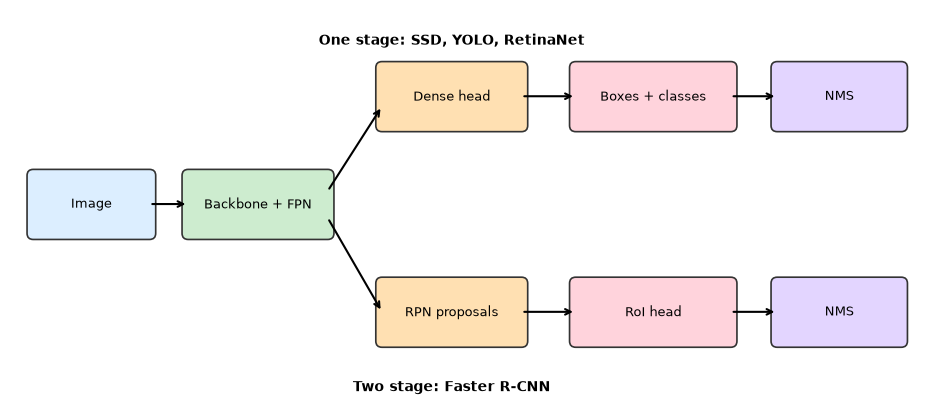

In [18]:
fig, axis = plt.subplots(figsize=(12, 5))
axis.set_xlim(0, 12)
axis.set_ylim(0, 5)
axis.axis("off")

def draw_box(x, y, width, text, color):
    patch = FancyBboxPatch(
        (x, y), width, 0.75, boxstyle="round,pad=0.08",
        facecolor=color, edgecolor="#333333", linewidth=1.2,
    )
    axis.add_patch(patch)
    axis.text(x + width / 2, y + 0.375, text, ha="center", va="center", fontsize=9)

def arrow(x1, y1, x2, y2):
    axis.annotate("", (x2, y2), (x1, y1), arrowprops={"arrowstyle": "->", "lw": 1.5})

draw_box(0.3, 2.1, 1.5, "Image", "#dceeff")
draw_box(2.3, 2.1, 1.8, "Backbone + FPN", "#cdeccf")
arrow(1.8, 2.48, 2.3, 2.48)

draw_box(4.8, 3.5, 1.8, "Dense head", "#ffe0b2")
draw_box(7.3, 3.5, 2.0, "Boxes + classes", "#ffd3dc")
draw_box(9.9, 3.5, 1.6, "NMS", "#e3d5ff")
arrow(4.1, 2.65, 4.8, 3.75)
arrow(6.6, 3.88, 7.3, 3.88)
arrow(9.3, 3.88, 9.9, 3.88)
axis.text(5.7, 4.55, "One stage: SSD, YOLO, RetinaNet", ha="center", weight="bold")

draw_box(4.8, 0.7, 1.8, "RPN proposals", "#ffe0b2")
draw_box(7.3, 0.7, 2.0, "RoI head", "#ffd3dc")
draw_box(9.9, 0.7, 1.6, "NMS", "#e3d5ff")
arrow(4.1, 2.3, 4.8, 1.08)
arrow(6.6, 1.08, 7.3, 1.08)
arrow(9.3, 1.08, 9.9, 1.08)
axis.text(5.7, 0.05, "Two stage: Faster R-CNN", ha="center", weight="bold")

plt.show()

## 8. Transformers in object detection

The detectors above emphasize CNNs because they make the traditional detection pipeline easy to see, but a detector does not fundamentally require an exclusively CNN-based architecture. CNN and transformer components can be combined in several ways:

- a CNN backbone with a conventional CNN detection head, as in many classic detectors;
- a transformer backbone with a conventional head such as Faster R-CNN;
- a CNN backbone followed by a transformer detection head, as in the original DETR design;
- a transformer backbone together with transformer-based detection components.

### DETR and object queries

DETR reformulates detection as direct **set prediction**. Image features become tokens for a transformer, and a fixed collection of learned **object queries** is passed through the decoder. Each output query predicts one class—including a special `no object` class—and one bounding box:

```text
image -> visual features -> transformer encoder/decoder
                         + learned object queries
                         -> one class and box per query
```

During training, a one-to-one matching algorithm pairs predicted queries with ground-truth objects. Unmatched queries learn to predict `no object`. This set-level training discourages several queries from receiving credit for the same object.

The original DETR pipeline therefore does not require predefined anchors, an external proposal algorithm, RoI Pooling, or traditional greedy NMS. Its transformer can also use information from distant image regions when deciding what each query should represent.

This does not mean that every transformer detector removes all traditional components. Later designs mix CNNs, transformer backbones, feature pyramids, multiscale attention, proposals, or NMS in different combinations. *Transformer-based*, *anchor-free*, *one-stage*, and *NMS-free* describe different design choices and are not interchangeable terms.

Regardless of the architecture, the detector must still localize and classify objects, and we can still evaluate its boxes using IoU, precision, recall, AP, and mAP.

## 9. What remains common

Despite architectural differences, most conventional detectors must solve the same underlying problems:

1. extract useful visual features;
2. decide which locations or regions represent objects;
3. predict class scores and box coordinates;
4. train classification and localization objectives together;
5. remove redundant predictions;
6. evaluate class-specific ranked detections with AP.

This perspective is more durable than memorizing model names: architectures mainly differ in where candidates come from, how features are assigned to them, and whether refinement happens in one stage or multiple stages.

## Reflection

Answer briefly in your own words.

1. Why does a detector produce many candidate boxes rather than one output per image?
2. What is an anchor, and what does the network predict relative to it?
3. Why are some anchors ignored during training?
4. What expensive repetition did Fast R-CNN remove from the original R-CNN?
5. What did Faster R-CNN add to Fast R-CNN?
6. What is the main structural difference between a one-stage and a two-stage detector?
7. Why is foreground–background imbalance especially severe in dense one-stage detection?
8. How does an anchor-free detector differ from an anchor-based detector?
9. Why are feature pyramids useful for object detection?
10. How does the original DETR pipeline differ from an anchor-based detector with NMS?

### Answers

1. Image can contain a variable number of objects at different positions and scales. Many candidates allow the detector to represent these different possible objects; one classification-style output cannot naturally do that.
2. anchor is a predefined reference box attached to an image feature-map location. The model predicts class or objectness scores and four offsets that move and resize the anchor into a predicted box.
3. IoU metric is above negative threshold and below positive threshold. Anchors with IoU between the thresholds are ambiguous: they are neither clearly foreground nor clearly background. Ignoring them avoids giving the model uncertain training targets
4. CNN layer run through each proposal box. original R-CNN ran the CNN separately for every proposed image crop; Fast R-CNN runs the CNN once and extracts all proposal features from the shared feature map.
5. Learnable proposal boxes wiht region proposal network. Faster R-CNN added a learned Region Proposal Network that shares the backbone features.
6. A one-stage detector turns dense-head outputs directly into final detection candidates. A two-stage detector first selects proposals and then processes each selected proposal with a separate RoI head. Avoid saying that every one-stage detector checks anchors because some are anchor-free.
7. cause they check all possible anchor boxes (in case of anchor-based detector) and most of them are background. Dense detectors evaluate many feature-map locations or candidates, but only a small fraction correspond to objects. Most are background, so easy negative examples can overwhelm the relatively rare foreground examples
8. An anchor-based detector predicts offsets relative to predefined reference boxes. An anchor-free detector predicts a box directly relative to a feature location—for example, distances to its left, top, right, and bottom boundaries.
9. to detect some object better to have deeper semantic data but for other (usually small object) better to have spatial data. High-resolution levels retain spatial detail useful for small objects, while deeper low-resolution levels provide stronger semantic features and larger receptive fields for larger objects.
10. DETR has transformer detection head and uses learned object queries to match predictions and ground truth. It does not need to have predefined anchors, region proposals or NMS. DETR uses learned object queries and one-to-one set matching, removing the need for predefined anchors, proposals, RoI Pooling, and traditional NMS in the original design.